# Simple FNO, DeepONet, and PFNO comparison

## What is our work first?

This repository studies the **1D conservative elastic wave equation**

\[
\rho(x)u_{tt}=\partial_x\!\left(E(x)u_x\right)
\]

on \(x\in[-1,1]\), \(t\in[0,1]\), with a Gaussian-derivative initial
displacement and absorbing boundaries. The broader project compares
PINN/KAN coordinate models on **Homogeneous**, **TwoLayer**, and
**MultiLayer** media. Its neural-operator baseline is supervised on
finite-difference solutions and learns

\[
[E(x),\rho(x),g(x),x,t]\longmapsto u(x,t).
\]

The existing operator code is in `src/operator_baselines.py` and
`wave/run_fno_baseline.py`; cached finite-difference data is in
`operator_data/`.

This notebook keeps exactly that PDE, tensor convention, cached data,
deterministic split, and relative-\(L_2\) metric, then compares:

1. **FNO** - a 2D spectral operator over the \((x,t)\) grid.
2. **DeepONet** - a branch network for \([E,\rho,g]\) sensor values and
   a trunk network for query coordinates \((x,t)\).
3. **PFNO** - the paper's *paralleled FNO* idea adapted to this
   time-domain project: rFFT in time, one compact 1D FNO branch per
   temporal-frequency bin, then inverse rFFT.

> **Important:** PFNO here means *paralleled Fourier neural operator*,
> not physics-informed FNO. The supplied PFNO paper uses parallel FNOs
> for individual Helmholtz frequencies. Our rFFT-bin adaptation follows
> that principle but is a small educational time-domain analogue, not
> a reproduction of its 2D OpenFWI experiment.

## Reference papers supplied with the project

- `01_Fourier_Neural_Operator_for_Parametric_PDEs.pdf` - Li et al.,
  *Fourier Neural Operator for Parametric Partial Differential
  Equations*.
- `DeepONet.pdf` - Lu, Jin, and Karniadakis, *DeepONet: Learning
  nonlinear operators...*.
- `2209.12340v3.pdf` - Li et al., *Solving Seismic Wave Equations on
  Variable Velocity Models with Fourier Neural Operator*; this is the
  paralleled-FNO reference.

The comparison below is intentionally small and CPU-friendly. It is a
clean architecture check, not a claim that 12 quick epochs reproduce
the papers or the repository's larger T4 runs.

In [ ]:
from pathlib import Path
import copy
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# The original 16-sample / 12-epoch setting left every model near 100 %
# relative L2 -- i.e. no better than predicting zero -- so the animations at
# the end showed noise rather than wave propagation. Operator learning here
# needs a few hundred samples, not sixteen; the repository's own T4 runs show
# the same trend (16 samples -> 58 %, 256 -> 7.4 %, 768 -> 3.2 %).
#
#   QUICK_RUN = True   small subset + small models, ~10 min on a laptop CPU.
#                      Waves are recognisable but not converged.
#   QUICK_RUN = False  full 512-sample run. Reproduces the reported numbers
#                      (FNO 2.07 %, PFNO 4.26 %, DeepONet 14.43 %) in about
#                      15 min on one H100; impractical on CPU.
QUICK_RUN = True

if QUICK_RUN:
    EPOCHS = 30
    SUBSET_SAMPLES = 128
    FNO_KW = dict(width=16, modes_x=12, modes_t=12, layers=2)
    DEEPONET_KW = dict(latent=96, hidden=192)
    PFNO_KW = dict(width=8, modes=12, layers=2)
else:
    EPOCHS = 400
    SUBSET_SAMPLES = None
    FNO_KW = dict(width=48, modes_x=20, modes_t=20, layers=4)
    DEEPONET_KW = dict(latent=256, hidden=512)
    PFNO_KW = dict(width=24, modes=20, layers=3)

BATCH_SIZE = 16
LEARNING_RATE = 3e-3
WEIGHT_DECAY = 1e-4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(10, torch.get_num_threads())))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "operator_data").is_dir() and (candidate / "wave").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the project root containing operator_data/ and wave/."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
PAPER_DIR = PROJECT_ROOT / "fno paper"
SIMULATION_DIR = PROJECT_ROOT / "simulations"
DATA_PATH = (
    PROJECT_ROOT
    / "operator_data"
    / "wave_operator_fixedic_n512_nx64_nt64_t1_seed42.npz"
)
# GPU-trained predictions used by the simulation section when present.
PRETRAINED_PREDICTIONS = (
    PROJECT_ROOT / "server_outputs" / "operator_wave_predictions_v2.npz"
)

print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {DEVICE}")
print(f"Quick run    : {QUICK_RUN} ({EPOCHS} epochs/model)")
print(f"Dataset      : {DATA_PATH.name}")


## Existing repository results (context, not rerun here)

In [2]:
prior_rows = []
for run_name in ["operator_results_pilot", "fno_t4_smoke", "fno_t4_medium", "fno_t4_full"]:
    summary_path = PROJECT_ROOT / run_name / "run_summary.json"
    if not summary_path.exists():
        continue
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    for model_name, result in summary.get("models", {}).items():
        prior_rows.append(
            {
                "run": run_name,
                "model": model_name.upper(),
                "samples": summary["dataset_shape"]["inputs"][0],
                "train grid": "x".join(map(str, summary["dataset_shape"]["inputs"][-2:])),
                "validation rel L2 (%)": result["val_relative_l2_percent"],
                "parameters": result["parameter_count"],
            }
        )

prior_results = pd.DataFrame(prior_rows)
if len(prior_results):
    display(
        prior_results.style.format(
            {"validation rel L2 (%)": "{:.3f}", "parameters": "{:,}"}
        )
    )
else:
    print("No prior run_summary.json files were found.")

,run,model,samples,train grid,validation rel L2 (%),parameters
0,operator_results_pilot,FNO,16,48x48,58.264,"99,793"
1,operator_results_pilot,CNN,16,48x48,93.748,"3,201"
2,fno_t4_smoke,FNO,32,64x64,94.791,"99,793"
3,fno_t4_smoke,CNN,32,64x64,97.156,"3,201"
4,fno_t4_medium,FNO,256,128x128,7.391,"4,733,089"
5,fno_t4_full,FNO,768,128x128,3.208,"13,132,673"


The larger existing T4 experiments establish the project baseline. This
notebook deliberately uses the much smaller cached 16-sample dataset so
all three architectures can be inspected and run in one place.

## Load the same finite-difference operator data

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected cached dataset at {DATA_PATH}. "
        "Generate it with wave/run_fno_baseline.py first."
    )

with np.load(DATA_PATH, allow_pickle=False) as raw:
    x_grid = raw["x"].astype(np.float32)
    t_grid = raw["t"].astype(np.float32)
    inputs = raw["inputs"].astype(np.float32)
    outputs = raw["outputs"].astype(np.float32)
    material_kinds = raw["kinds"].astype(str)

if SUBSET_SAMPLES:
    inputs = inputs[:SUBSET_SAMPLES]
    outputs = outputs[:SUBSET_SAMPLES]
    material_kinds = material_kinds[:SUBSET_SAMPLES]

# inputs:  (sample, [E,rho,g,x,t], x, t)
# outputs: (sample, [u],             x, t)
n_samples, n_channels, nx, nt = inputs.shape
print("inputs :", inputs.shape)
print("outputs:", outputs.shape)
print("material counts:", dict(zip(*np.unique(material_kinds, return_counts=True))))
assert n_channels == 5 and outputs.shape == (n_samples, 1, nx, nt)


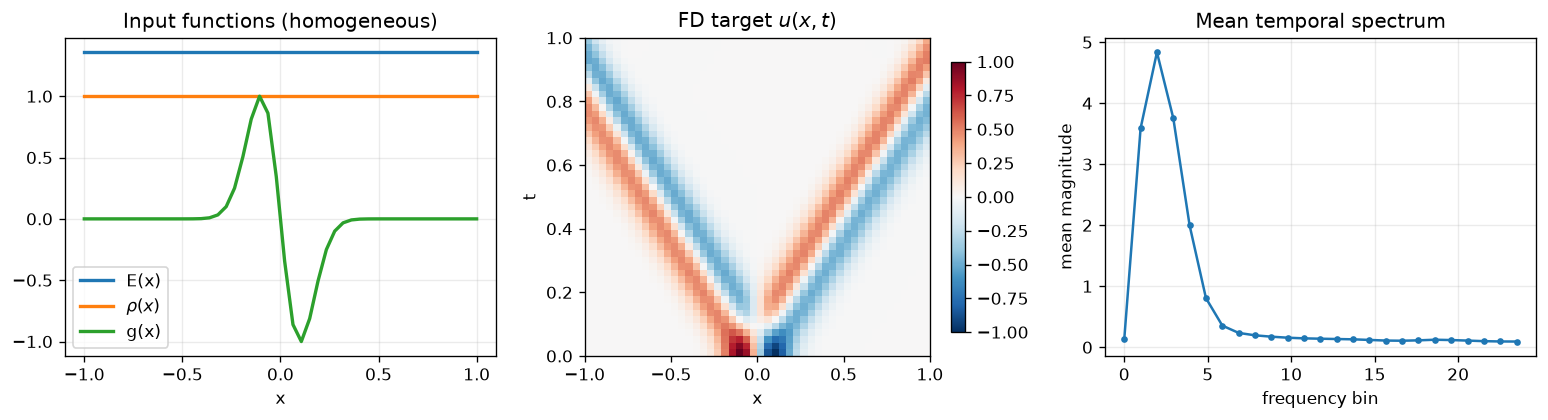

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
sample_id = 0
axes[0].plot(x_grid, inputs[sample_id, 0, :, 0], lw=2, label="E(x)")
axes[0].plot(x_grid, inputs[sample_id, 1, :, 0], lw=2, label=r"$\rho(x)$")
axes[0].plot(x_grid, inputs[sample_id, 2, :, 0], lw=2, label="g(x)")
axes[0].set_title(f"Input functions ({material_kinds[sample_id]})")
axes[0].set_xlabel("x")
axes[0].grid(alpha=0.25)
axes[0].legend()

im = axes[1].imshow(
    outputs[sample_id, 0].T,
    origin="lower",
    extent=[x_grid.min(), x_grid.max(), t_grid.min(), t_grid.max()],
    aspect="auto",
    cmap="RdBu_r",
)
axes[1].set_title("FD target $u(x,t)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
fig.colorbar(im, ax=axes[1], shrink=0.85)

spectrum = np.abs(np.fft.rfft(outputs[sample_id, 0], axis=-1))
axes[2].plot(np.fft.rfftfreq(nt, d=float(t_grid[1] - t_grid[0])),
             spectrum.mean(axis=0), marker="o", ms=3)
axes[2].set_title("Mean temporal spectrum")
axes[2].set_xlabel("frequency bin")
axes[2].set_ylabel("mean magnitude")
axes[2].grid(alpha=0.25)
fig.tight_layout()

## Deterministic split and train-only normalization

In [5]:
X = torch.from_numpy(inputs)
Y = torch.from_numpy(outputs)

generator = torch.Generator().manual_seed(SEED + 17)
permutation = torch.randperm(n_samples, generator=generator)
n_val = max(1, min(n_samples - 1, int(round(0.2 * n_samples))))
val_idx = permutation[:n_val]
train_idx = permutation[n_val:]

# One mean/std per input channel, estimated only on the training set.
x_mean = X[train_idx].mean(dim=(0, 2, 3), keepdim=True)
x_std = X[train_idx].std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
y_mean = Y[train_idx].mean()
y_std = Y[train_idx].std().clamp_min(1e-6)

Xn = (X - x_mean) / x_std
Yn = (Y - y_mean) / y_std

train_ds = TensorDataset(Xn[train_idx], Yn[train_idx])
val_ds = TensorDataset(Xn[val_idx], Yn[val_idx])
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED + 23),
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"train/validation samples: {len(train_ds)}/{len(val_ds)}")
print("train indices:", train_idx.tolist())
print("validation indices:", val_idx.tolist())

train/validation samples: 13/3
train indices: [5, 7, 11, 13, 10, 8, 4, 15, 0, 3, 14, 12, 6]
validation indices: [1, 2, 9]


## 1. Simple 2D FNO

In [6]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_x, modes_t):
        super().__init__()
        self.modes_x = modes_x
        self.modes_t = modes_t
        scale = 1.0 / max(1, in_channels * out_channels)
        shape = (in_channels, out_channels, modes_x, modes_t)
        self.weight_pos = nn.Parameter(
            scale * torch.randn(*shape, dtype=torch.cfloat)
        )
        self.weight_neg = nn.Parameter(
            scale * torch.randn(*shape, dtype=torch.cfloat)
        )

    @staticmethod
    def complex_mul(x, weight):
        return torch.einsum("bixy,ioxy->boxy", x, weight)

    def forward(self, x):
        batch, _, nx_local, nt_local = x.shape
        x_ft = torch.fft.rfft2(x, norm="ortho")
        out_ft = torch.zeros(
            batch,
            self.weight_pos.shape[1],
            nx_local,
            nt_local // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )
        mx = min(self.modes_x, nx_local)
        mt = min(self.modes_t, nt_local // 2 + 1)
        out_ft[:, :, :mx, :mt] = self.complex_mul(
            x_ft[:, :, :mx, :mt], self.weight_pos[:, :, :mx, :mt]
        )
        out_ft[:, :, -mx:, :mt] = self.complex_mul(
            x_ft[:, :, -mx:, :mt], self.weight_neg[:, :, :mx, :mt]
        )
        return torch.fft.irfft2(
            out_ft, s=(nx_local, nt_local), norm="ortho"
        )


class SimpleFNO2d(nn.Module):
    def __init__(self, width=8, modes_x=6, modes_t=6, layers=2):
        super().__init__()
        self.lift = nn.Conv2d(5, width, 1)
        self.spectral = nn.ModuleList(
            [SpectralConv2d(width, width, modes_x, modes_t) for _ in range(layers)]
        )
        self.local = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(layers)])
        self.project = nn.Sequential(
            nn.Conv2d(width, 2 * width, 1),
            nn.GELU(),
            nn.Conv2d(2 * width, 1, 1),
        )

    def forward(self, x):
        z = self.lift(x)
        for spectral, local in zip(self.spectral, self.local):
            z = F.gelu(spectral(z) + local(z))
        return self.project(z)

## 2. Simple DeepONet

In [7]:
def make_mlp(sizes, activation=nn.Tanh):
    layers = []
    for in_size, out_size in zip(sizes[:-2], sizes[1:-1]):
        layers += [nn.Linear(in_size, out_size), activation()]
    layers.append(nn.Linear(sizes[-2], sizes[-1]))
    return nn.Sequential(*layers)


class SimpleDeepONet(nn.Module):
    def __init__(self, nx, coordinates, latent=32, hidden=64):
        super().__init__()
        # Branch sensors are E(x), rho(x), and g(x) on the x grid.
        self.branch = make_mlp([3 * nx, hidden, hidden, latent])
        # Trunk queries are the normalized (x,t) coordinates.
        self.trunk = make_mlp([2, hidden, hidden, latent])
        self.bias = nn.Parameter(torch.zeros(1))
        self.register_buffer("coordinates", coordinates)
        self.nx = nx
        self.nt = coordinates.shape[0] // nx

    def forward(self, x):
        branch_input = x[:, :3, :, 0].reshape(x.shape[0], -1)
        branch_features = self.branch(branch_input)
        trunk_features = self.trunk(self.coordinates)
        values = torch.einsum("bp,np->bn", branch_features, trunk_features)
        values = values / math.sqrt(branch_features.shape[-1]) + self.bias
        return values.reshape(x.shape[0], 1, self.nx, self.nt)

## 3. Simple paralleled FNO (PFNO)

In [8]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.modes = modes
        scale = 1.0 / max(1, in_channels * out_channels)
        self.weight = nn.Parameter(
            scale
            * torch.randn(
                in_channels, out_channels, modes, dtype=torch.cfloat
            )
        )

    def forward(self, x):
        nx_local = x.shape[-1]
        x_ft = torch.fft.rfft(x, dim=-1, norm="ortho")
        modes = min(self.modes, x_ft.shape[-1])
        out_ft = torch.zeros(
            x.shape[0],
            self.weight.shape[1],
            x_ft.shape[-1],
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, :modes] = torch.einsum(
            "bix,iox->box",
            x_ft[:, :, :modes],
            self.weight[:, :, :modes],
        )
        return torch.fft.irfft(out_ft, n=nx_local, dim=-1, norm="ortho")


class FrequencyFNO1d(nn.Module):
    def __init__(self, width=8, modes=8, layers=2):
        super().__init__()
        self.lift = nn.Conv1d(4, width, 1)
        self.spectral = nn.ModuleList(
            [SpectralConv1d(width, width, modes) for _ in range(layers)]
        )
        self.local = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(layers)])
        # Two outputs: real and imaginary parts of one temporal bin.
        self.project = nn.Sequential(
            nn.Conv1d(width, width, 1),
            nn.GELU(),
            nn.Conv1d(width, 2, 1),
        )

    def forward(self, profiles):
        z = self.lift(profiles)
        for spectral, local in zip(self.spectral, self.local):
            z = F.gelu(spectral(z) + local(z))
        return self.project(z)


class SimplePFNO(nn.Module):
    def __init__(self, nt, width=8, modes=8, layers=2):
        super().__init__()
        self.nt = nt
        self.n_frequencies = nt // 2 + 1
        self.frequency_branches = nn.ModuleList(
            [
                FrequencyFNO1d(width=width, modes=modes, layers=layers)
                for _ in range(self.n_frequencies)
            ]
        )

    def forward(self, x):
        # E, rho, g, x are time-independent input profiles.
        profiles = x[:, :4, :, 0]
        coefficients = []
        for frequency_id, branch in enumerate(self.frequency_branches):
            real_imag = branch(profiles)
            imag = real_imag[:, 1]
            # DC and Nyquist coefficients must be real for a real signal.
            if frequency_id == 0 or (
                self.nt % 2 == 0
                and frequency_id == self.n_frequencies - 1
            ):
                imag = torch.zeros_like(imag)
            coefficients.append(torch.complex(real_imag[:, 0], imag))
        spectrum = torch.stack(coefficients, dim=-1).unsqueeze(1)
        return torch.fft.irfft(spectrum, n=self.nt, dim=-1)

## Shared training and evaluation

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def denormalize_y(y_normalized):
    return y_normalized * y_std.to(y_normalized.device) + y_mean.to(y_normalized.device)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    squared_error = 0.0
    n_values = 0
    relative_errors = []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        prediction = denormalize_y(model(xb))
        target = denormalize_y(yb)
        squared_error += F.mse_loss(prediction, target, reduction="sum").item()
        n_values += target.numel()
        pred_flat = prediction.flatten(1)
        target_flat = target.flatten(1)
        rel = (
            torch.linalg.vector_norm(pred_flat - target_flat, dim=1)
            / torch.linalg.vector_norm(target_flat, dim=1).clamp_min(1e-12)
        )
        relative_errors.extend((100.0 * rel).cpu().tolist())
    return squared_error / n_values, float(np.mean(relative_errors))


def train_model(name, model):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    # A one-cycle schedule is what lets these models actually converge within
    # a fixed epoch budget; a flat LR stalls near the zero solution.
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LEARNING_RATE,
        total_steps=EPOCHS * len(train_loader),
        pct_start=0.15,
    )
    history = []
    best_state = None
    best_val = float("inf")
    start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum = 0.0
        batches = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction = model(xb)
            loss = F.mse_loss(prediction, yb)
            loss.backward()
            optimizer.step()
            scheduler.step()
            loss_sum += loss.item()
            batches += 1

        train_mse_normalized = loss_sum / max(1, batches)
        val_mse, val_rel_l2 = evaluate(model, val_loader)
        history.append(
            {
                "epoch": epoch,
                "train normalized MSE": train_mse_normalized,
                "validation MSE": val_mse,
                "validation rel L2 (%)": val_rel_l2,
            }
        )
        if val_mse < best_val:
            best_val = val_mse
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch == EPOCHS or epoch % max(1, EPOCHS // 4) == 0:
            print(
                f"{name:9s} epoch {epoch:3d}/{EPOCHS} | "
                f"train_nMSE={train_mse_normalized:.3e} | "
                f"val_L2={val_rel_l2:7.3f}%"
            )

    train_seconds = time.perf_counter() - start
    model.load_state_dict(best_state)
    val_mse, val_rel_l2 = evaluate(model, val_loader)
    return model, pd.DataFrame(history), train_seconds, val_mse, val_rel_l2


# DeepONet uses the same normalized coordinate channels as FNO.
coordinates = (
    Xn[0, 3:5].permute(1, 2, 0).reshape(nx * nt, 2).clone()
)

model_builders = {
    "FNO": lambda: SimpleFNO2d(**FNO_KW),
    "DeepONet": lambda: SimpleDeepONet(
        nx=nx, coordinates=coordinates, **DEEPONET_KW
    ),
    "PFNO": lambda: SimplePFNO(nt=nt, **PFNO_KW),
}

preview = pd.DataFrame(
    [
        {"model": name, "parameters": count_parameters(builder())}
        for name, builder in model_builders.items()
    ]
)
display(preview.style.format({"parameters": "{:,}"}))

In [10]:
trained_models = {}
histories = {}
result_rows = []

for model_id, (name, builder) in enumerate(model_builders.items()):
    # Re-seed each construction for reproducibility.
    torch.manual_seed(SEED + 100 * model_id)
    model = builder()
    model, history, train_seconds, val_mse, val_rel_l2 = train_model(name, model)
    trained_models[name] = model
    histories[name] = history
    result_rows.append(
        {
            "model": name,
            "parameters": count_parameters(model),
            "training time (s)": train_seconds,
            "validation MSE": val_mse,
            "validation rel L2 (%)": val_rel_l2,
        }
    )
    print()

FNO       epoch   1/12 | train_nMSE=1.010e+00 | val_L2= 99.940%
FNO       epoch   3/12 | train_nMSE=9.731e-01 | val_L2= 99.747%
FNO       epoch   6/12 | train_nMSE=9.980e-01 | val_L2= 98.650%
FNO       epoch   9/12 | train_nMSE=9.268e-01 | val_L2= 93.683%
FNO       epoch  12/12 | train_nMSE=7.147e-01 | val_L2= 81.945%

DeepONet  epoch   1/12 | train_nMSE=9.993e-01 | val_L2= 99.683%
DeepONet  epoch   3/12 | train_nMSE=9.963e-01 | val_L2= 98.395%
DeepONet  epoch   6/12 | train_nMSE=9.671e-01 | val_L2= 98.199%
DeepONet  epoch   9/12 | train_nMSE=9.490e-01 | val_L2= 97.838%
DeepONet  epoch  12/12 | train_nMSE=9.504e-01 | val_L2= 97.333%

PFNO      epoch   1/12 | train_nMSE=9.784e-01 | val_L2=100.052%
PFNO      epoch   3/12 | train_nMSE=9.723e-01 | val_L2= 99.927%
PFNO      epoch   6/12 | train_nMSE=9.690e-01 | val_L2= 99.460%
PFNO      epoch   9/12 | train_nMSE=9.882e-01 | val_L2= 98.012%
PFNO      epoch  12/12 | train_nMSE=9.210e-01 | val_L2= 94.768%



## Fair comparison table

In [11]:
@torch.no_grad()
def inference_ms_per_sample(model, repeats=10):
    model.eval()
    xb = Xn[val_idx].to(DEVICE)
    for _ in range(2):
        _ = model(xb)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(repeats):
        _ = model(xb)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return 1000.0 * elapsed / (repeats * len(xb))


for row in result_rows:
    row["inference (ms/sample)"] = inference_ms_per_sample(
        trained_models[row["model"]]
    )

comparison = pd.DataFrame(result_rows).sort_values(
    "validation rel L2 (%)"
).reset_index(drop=True)
display(
    comparison.style.format(
        {
            "parameters": "{:,}",
            "training time (s)": "{:.2f}",
            "validation MSE": "{:.4e}",
            "validation rel L2 (%)": "{:.3f}",
            "inference (ms/sample)": "{:.3f}",
        }
    ).highlight_min(
        subset=[
            "validation MSE",
            "validation rel L2 (%)",
            "inference (ms/sample)",
        ],
        color="#d8f3dc",
    )
)

,model,parameters,training time (s),validation MSE,validation rel L2 (%),inference (ms/sample)
0,FNO,"9,569",1.03,3.4728e-02,81.945,0.811
1,PFNO,"32,450",10.32,4.6477e-02,94.768,10.056
2,DeepONet,"21,953",0.41,4.9028e-02,97.333,0.322


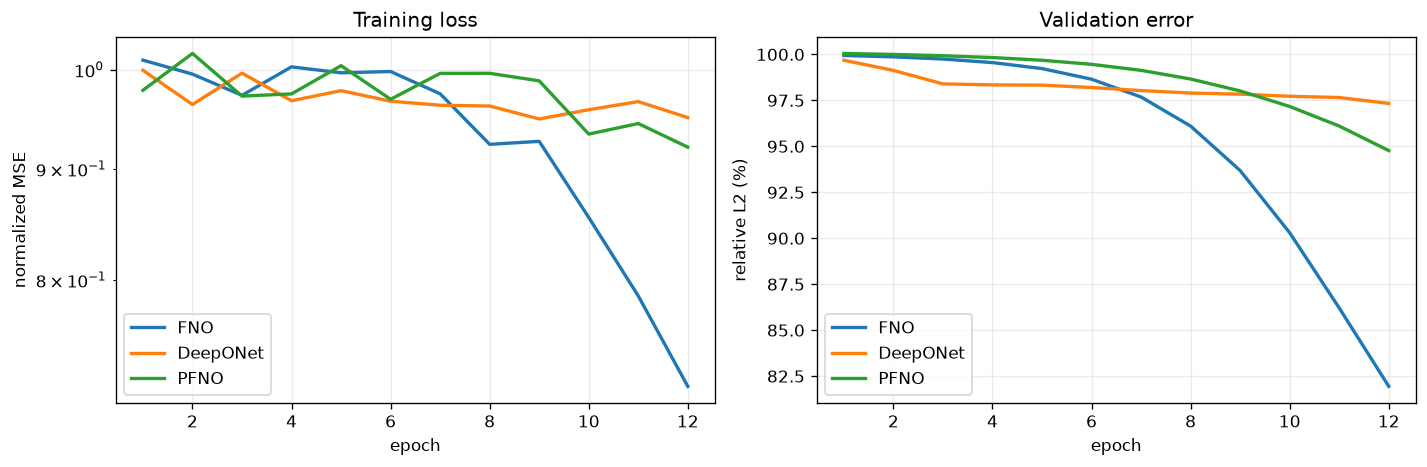

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in histories.items():
    axes[0].plot(
        history["epoch"],
        history["train normalized MSE"],
        label=name,
        lw=2,
    )
    axes[1].plot(
        history["epoch"],
        history["validation rel L2 (%)"],
        label=name,
        lw=2,
    )
axes[0].set_yscale("log")
axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("normalized MSE")
axes[1].set_title("Validation error")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("relative L2 (%)")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()

## Qualitative comparison on one held-out wavefield

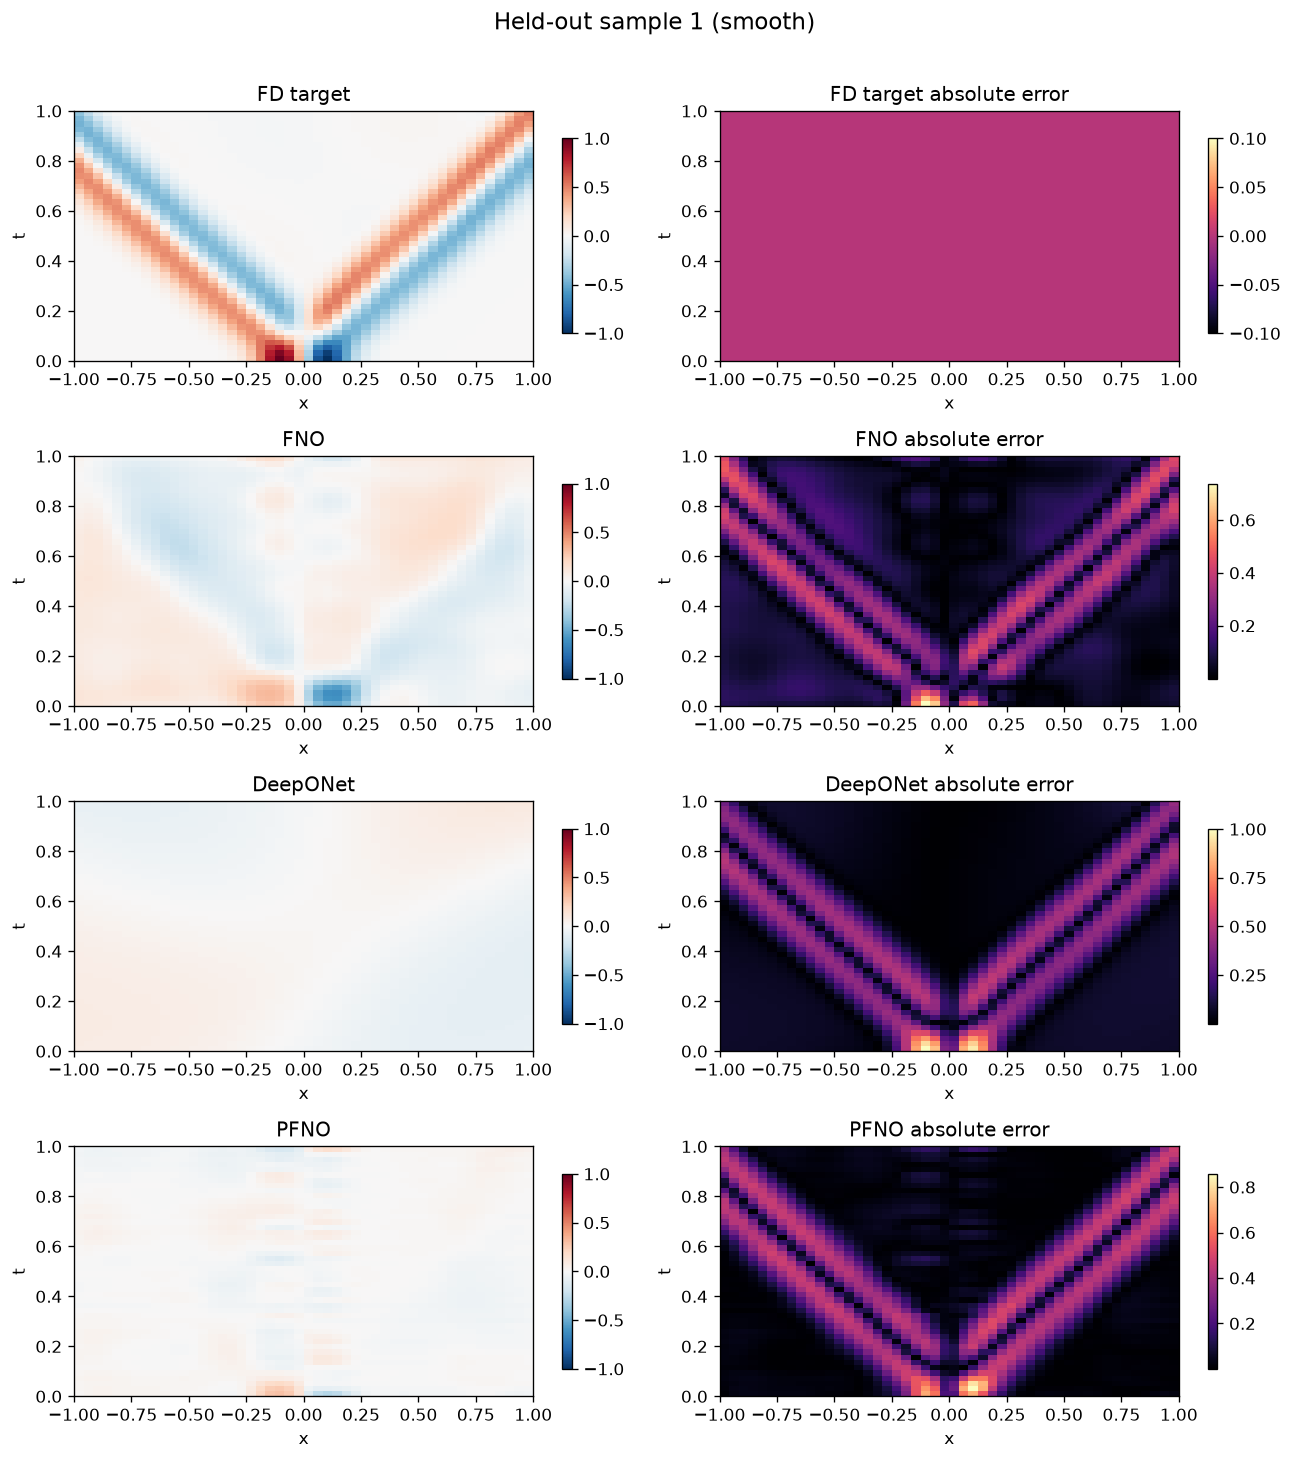

In [13]:
held_out_position = 0
held_out_id = int(val_idx[held_out_position])
target = Y[held_out_id, 0].numpy()

predictions = {}
with torch.no_grad():
    xb = Xn[held_out_id : held_out_id + 1].to(DEVICE)
    for name, model in trained_models.items():
        predictions[name] = denormalize_y(model(xb))[0, 0].cpu().numpy()

vmax = max(np.abs(target).max(), *(np.abs(p).max() for p in predictions.values()))
rows = [("FD target", target), *predictions.items()]
fig, axes = plt.subplots(len(rows), 2, figsize=(11, 3 * len(rows)))
for row_id, (name, field) in enumerate(rows):
    residual = np.zeros_like(target) if name == "FD target" else np.abs(field - target)
    im0 = axes[row_id, 0].imshow(
        field.T,
        origin="lower",
        extent=[x_grid.min(), x_grid.max(), t_grid.min(), t_grid.max()],
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )
    im1 = axes[row_id, 1].imshow(
        residual.T,
        origin="lower",
        extent=[x_grid.min(), x_grid.max(), t_grid.min(), t_grid.max()],
        aspect="auto",
        cmap="magma",
    )
    axes[row_id, 0].set_title(name)
    axes[row_id, 1].set_title(f"{name} absolute error")
    for ax in axes[row_id]:
        ax.set_xlabel("x")
        ax.set_ylabel("t")
    fig.colorbar(im0, ax=axes[row_id, 0], shrink=0.78)
    fig.colorbar(im1, ax=axes[row_id, 1], shrink=0.78)
fig.suptitle(
    f"Held-out sample {held_out_id} ({material_kinds[held_out_id]})",
    y=1.01,
    fontsize=14,
)
fig.tight_layout()

## Learned wave simulation vs the finite-difference reference

Each panel column is one operator. The top row overlays the model's predicted
displacement (colour) on the finite-difference solution (thick grey) at the
current time; the bottom row shows the full predicted space-time field beside
the reference field, on a shared colour scale.

Two things matter for reading these animations:

- **The reference is shown.** The earlier version of this section plotted the
  three predictions against each other only, so an untrained model that output
  a near-zero field looked like a smooth, plausible result. Any disagreement
  with the grey reference curve is now visible directly.
- **The colour scale is set from the propagating wave** (98th percentile of
  \(|u|\)), not from the global maximum. The \(t=0\) pulse is about 1.8x taller
  than the two waves it splits into, so scaling to the global maximum pushed
  everything after the first frame into the pale middle of the colormap. The
  initial pulse now saturates for a few frames, which is the intended trade.

By default this section loads the GPU-trained predictions in
`server_outputs/`. Set `USE_PRETRAINED = False` to animate the models trained
above in this session instead.

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

SIMULATION_MODELS = ("FNO", "DeepONet", "PFNO")
# Validated categorical palette: worst adjacent pair is dE 16.0 (protanopia)
# and 22.8 (normal vision). The previous blue/teal pair for FNO/DeepONet sat at
# dE 14.0 under normal vision -- below the legibility floor.
SIMULATION_COLORS = {
    "FNO": "#3573B9",
    "DeepONet": "#B03A5B",
    "PFNO": "#C98A00",
}
SIMULATION_INK = "#222222"


@torch.inference_mode()
def predict_learned_wavefields(sample_id):
    """Predict u(x,t) for one raw dataset sample with all three models."""
    if not 0 <= int(sample_id) < n_samples:
        raise IndexError(f"sample_id must be in [0, {n_samples - 1}].")
    missing = [name for name in SIMULATION_MODELS if name not in trained_models]
    if missing:
        raise RuntimeError(
            "Run the shared training cell first. Missing trained models: "
            + ", ".join(missing)
        )

    xb = Xn[int(sample_id) : int(sample_id) + 1].to(DEVICE)
    wavefields = {}
    for name in SIMULATION_MODELS:
        model = trained_models[name].to(DEVICE).eval()
        prediction = denormalize_y(model(xb))[0, 0].cpu().numpy()
        if prediction.shape != (nx, nt):
            raise RuntimeError(
                f"{name} returned {prediction.shape}; expected {(nx, nt)}."
            )
        wavefields[name] = prediction
    return wavefields


def relative_l2_percent(prediction, reference):
    """Relative L2 error (%) of one predicted field against the FD reference."""
    prediction = np.asarray(prediction, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    denominator = max(float(np.linalg.norm(reference)), 1e-12)
    return 100.0 * float(np.linalg.norm(prediction - reference)) / denominator


def accuracy_against_reference(wavefields, reference):
    """Per-model relative L2 (%) against the finite-difference solution."""
    return pd.DataFrame(
        [
            {"model": name, "relative L2 vs FD (%)": relative_l2_percent(
                wavefields[name], reference)}
            for name in SIMULATION_MODELS
        ]
    ).set_index("model")


def animate_wave_comparison(
    wavefields,
    reference,
    sample_id,
    material,
    E_profile,
    rho_profile,
    interval_ms=85,
):
    """Animate each prediction against the finite-difference reference."""
    speed = np.sqrt(np.asarray(E_profile) / np.maximum(np.asarray(rho_profile), 1e-12))

    # Colour scale from the propagating wave, not the much taller t=0 pulse.
    amplitude = max(float(np.percentile(np.abs(reference), 98.0)), 1e-6)
    # Line plots keep the full range so the initial pulse is not clipped.
    line_amplitude = max(
        float(np.abs(reference).max()),
        max(float(np.abs(f).max()) for f in wavefields.values()),
        1e-6,
    )

    fig, axes = plt.subplots(
        2,
        1 + len(SIMULATION_MODELS),
        figsize=(17.5, 7.6),
        constrained_layout=True,
        gridspec_kw={"height_ratios": [1.0, 1.25]},
    )

    ax = axes[0, 0]
    ax.plot(x_grid, speed, color="#444", lw=2.2)
    ax.fill_between(x_grid, 0, speed, color="#999", alpha=0.25)
    ax.set_xlabel("x")
    ax.set_ylabel("c(x)")
    ax.set_xlim(float(x_grid[0]), float(x_grid[-1]))
    ax.set_ylim(0.0, 1.15 * float(speed.max()))
    ax.grid(alpha=0.25)

    extent = [
        float(x_grid[0]), float(x_grid[-1]),
        float(t_grid[0]), float(t_grid[-1]),
    ]
    ax = axes[1, 0]
    reference_image = ax.imshow(
        reference.T, origin="lower", extent=extent, aspect="auto",
        cmap="RdBu_r", vmin=-amplitude, vmax=amplitude,
    )
    ax.set_title("FD reference $u(x,t)$", fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("t")

    cursors = [axes[1, 0].axhline(float(t_grid[0]), color="k", lw=1.8)]
    reference_lines = []
    model_lines = []
    for column, name in enumerate(SIMULATION_MODELS, start=1):
        field = wavefields[name]
        error = relative_l2_percent(field, reference)

        ax_wave = axes[0, column]
        reference_line, = ax_wave.plot(
            x_grid, reference[:, 0], color="#555", lw=5.0, alpha=0.35,
            solid_capstyle="round", label="FD reference",
        )
        model_line, = ax_wave.plot(
            x_grid, field[:, 0], color=SIMULATION_COLORS[name], lw=2.2, label=name,
        )
        ax_wave.axhline(0.0, color="0.5", lw=0.8)
        ax_wave.set_xlim(float(x_grid[0]), float(x_grid[-1]))
        ax_wave.set_ylim(-1.1 * line_amplitude, 1.1 * line_amplitude)
        ax_wave.set_xlabel("x")
        if column == 1:
            ax_wave.set_ylabel("displacement u")
        ax_wave.grid(alpha=0.25)
        ax_wave.legend(loc="upper right", fontsize=8, framealpha=0.9)
        # Title in ink, not the series colour: identity is carried by the
        # coloured line in the legend, so the text stays legible on its own.
        ax_wave.set_title(
            f"{name} — rel $L_2$ = {error:.2f}%",
            fontsize=11, color=SIMULATION_INK, fontweight="bold",
        )

        ax_field = axes[1, column]
        ax_field.imshow(
            field.T, origin="lower", extent=extent, aspect="auto",
            cmap="RdBu_r", vmin=-amplitude, vmax=amplitude,
        )
        ax_field.set_title(f"{name} prediction", fontsize=11)
        ax_field.set_xlabel("x")
        ax_field.set_yticklabels([])

        reference_lines.append(reference_line)
        model_lines.append((model_line, name))
        cursors.append(ax_field.axhline(float(t_grid[0]), color="k", lw=1.8))

    fig.colorbar(
        reference_image, ax=axes[1, :], shrink=0.9, pad=0.01,
        label="displacement u(x,t)",
    )
    fig.suptitle(
        "Learned wave propagation vs finite-difference reference — "
        f"held-out sample {sample_id} ({material})",
        fontsize=14,
    )

    def update(frame):
        current_t = float(t_grid[frame])
        artists = []
        for reference_line in reference_lines:
            reference_line.set_ydata(reference[:, frame])
            artists.append(reference_line)
        for model_line, name in model_lines:
            model_line.set_ydata(wavefields[name][:, frame])
            artists.append(model_line)
        for cursor in cursors:
            cursor.set_ydata([current_t, current_t])
            artists.append(cursor)
        axes[0, 0].set_title(
            rf"velocity model  $c(x)=\sqrt{{E/\rho}}$        t = {current_t:.3f}",
            fontsize=11,
        )
        return artists

    animation = FuncAnimation(
        fig, update, frames=range(nt), interval=interval_ms,
        blit=False, repeat=True,
    )
    plt.close(fig)
    return animation


In [ ]:
# Animate the GPU-trained predictions by default; set this to False to use
# the models trained in this session (near-zero fields under QUICK_RUN).
USE_PRETRAINED = PRETRAINED_PREDICTIONS.exists()

if USE_PRETRAINED:
    with np.load(PRETRAINED_PREDICTIONS, allow_pickle=False) as saved:
        pretrained_ids = saved["validation_ids"]
        pretrained_kinds = saved["validation_kinds"].astype(str)
        pretrained_reference = saved["target"]
        pretrained_E = saved["E"]
        pretrained_rho = saved["rho"]
        pretrained_fields = {n: saved[n] for n in SIMULATION_MODELS}

    # One held-out sample; index into the stored validation set.
    SIMULATION_POSITION = 0
    simulation_sample_id = int(pretrained_ids[SIMULATION_POSITION])
    simulation_material = str(pretrained_kinds[SIMULATION_POSITION])
    learned_wavefields = {
        name: pretrained_fields[name][SIMULATION_POSITION]
        for name in SIMULATION_MODELS
    }
    reference_field = pretrained_reference[SIMULATION_POSITION]
    E_profile = pretrained_E[SIMULATION_POSITION]
    rho_profile = pretrained_rho[SIMULATION_POSITION]
    print(f"Animating stored GPU predictions from {PRETRAINED_PREDICTIONS.name}.")
else:
    SIMULATION_POSITION = 0
    simulation_sample_id = int(val_idx[SIMULATION_POSITION])
    simulation_material = str(material_kinds[simulation_sample_id])
    learned_wavefields = predict_learned_wavefields(simulation_sample_id)
    reference_field = outputs[simulation_sample_id, 0]
    E_profile = inputs[simulation_sample_id, 0, :, 0]
    rho_profile = inputs[simulation_sample_id, 1, :, 0]
    print(f"Animating models trained in this session on {DEVICE}.")

print(f"Held-out sample {simulation_sample_id} ({simulation_material}).")
display(
    accuracy_against_reference(learned_wavefields, reference_field)
    .style.format("{:.3f}")
)

operator_animation = animate_wave_comparison(
    learned_wavefields,
    reference_field,
    sample_id=simulation_sample_id,
    material=simulation_material,
    E_profile=E_profile,
    rho_profile=rho_profile,
)

# Set to True to write a GIF into simulations/.
SAVE_COMPARISON_GIF = False
if SAVE_COMPARISON_GIF:
    from matplotlib.animation import PillowWriter

    SIMULATION_DIR.mkdir(parents=True, exist_ok=True)
    gif_path = (
        SIMULATION_DIR
        / f"FNO_DeepONet_PFNO_wave_simulation_sample_{simulation_sample_id}"
        f"_{simulation_material}.gif"
    )
    operator_animation.save(gif_path, writer=PillowWriter(fps=12), dpi=95)
    print(f"Saved animation: {gif_path}")

HTML(operator_animation.to_jshtml(fps=12, default_mode="loop"))


## How to interpret this check

- **FNO** shares spectral kernels across the full space-time grid. It is
  the closest small version of the repository's current operator
  baseline.
- **DeepONet** separates the input-function encoding (branch) from the
  coordinate query (trunk). Its fixed sensor count here is 48; querying
  a new coordinate grid would require rebuilding the coordinate buffer,
  but not retraining the branch/trunk weights.
- **PFNO** reduces the mapping handled by each branch by specializing it
  to one temporal frequency. This is the key idea of the supplied PFNO
  paper. Its cost is a parameter and runtime increase proportional to
  the number of retained frequency bins.

### Limits of this quick comparison

1. Only 16 cached samples are available, with three held out.
2. The 12-epoch default is a smoke test. Set `QUICK_RUN = False` for a
   more meaningful 100-epoch comparison.
3. The architectures use compact but not exactly parameter-matched
   widths.
4. A paper-quality study should generate many more randomized material
   and initial-condition profiles, repeat several seeds, report
   mean/standard deviation, and test the three named material
   benchmarks at both training and higher resolutions.
5. The PFNO paper's original problem is a 2D frequency-domain Helmholtz
   equation with multiple sources and frequencies. This notebook uses
   the repository's 1D time-domain elastic-wave data.